In [26]:
# Import library here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

In [27]:
df = pd.read_csv("../../data/processed/01.3/accidents_advance_clean.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Shape: (5469092, 42)
Columns: ['Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Duration(min)', 'Start_Date', 'Hour', 'Month', 'Weather_Group']


,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration(min),Start_Date,Hour,Month,Weather_Group
0,3,2016-11-08 08:50:37,29.718655,-95.321053,0.009950,Accident on I-45 Northbound at I-45 Exits 43A ...,I-45 N,Houston,Harris,TX,...,False,Day,Day,Day,Day,3.405079,2016-11-08,8,11,Cloudy
1,2,2021-07-26 07:04:56,38.927551,-121.080093,0.000000,Right hand shoulder blocked due to accident on...,Taylor Ln,Auburn,Placer,CA,...,False,Day,Day,Day,Day,3.862833,2021-07-26,7,7,Clear
2,2,2018-10-24 08:23:38,34.776241,-86.672829,0.000000,Lane blocked due to accident on AL-255 Researc...,Highway 255,Huntsville,Madison,AL,...,False,Day,Day,Day,Day,3.422633,2018-10-24,8,10,Clear
3,3,2019-07-11 10:42:48,42.384880,-83.149467,0.470004,Entry ramp to I-96 Westbound from Davison West...,Edward J Jeffries Fwy,Detroit,Wayne,MI,...,False,Day,Day,Day,Day,4.784571,2019-07-11,10,7,Clear
4,2,2020-11-06 01:29:00,33.776575,-117.837134,0.387980,1023: NB 55 JNO 22. SV REAR ENDED VV AND WAS L...,Garden Grove Fwy,Orange,Orange,CA,...,False,Night,Night,Night,Night,4.952535,2020-11-06,1,11,Clear
5,2,2021-07-02 15:22:00,36.989497,-121.935657,0.033435,Incident on PARK AVE WB near SOQUEL DR Expect ...,Park Ave N,Soquel,Santa Cruz,CA,...,False,Day,Day,Day,Day,5.758376,2021-07-02,15,7,Cloudy
6,2,2019-08-09 08:44:18,30.419380,-91.096611,0.000000,Accident on LA-73 Jefferson Hwy at LA-3064 Ess...,Essen Ln,Baton Rouge,East Baton Rouge,LA,...,False,Day,Day,Day,Day,4.665638,2019-08-09,8,8,Cloudy
7,2,2021-12-10 07:02:30,33.194519,-111.901301,1.015955,Stationary traffic on I-10 E - Pearl Harbor Me...,I-10 E,Maricopa,Pinal,AZ,...,False,Night,Day,Day,Day,4.248495,2021-12-10,7,12,Clear
8,3,2021-04-26 19:57:38,29.384928,-98.512321,0.000000,Three lanes blocked due to accident on I-35 So...,I-35 N,San Antonio,Bexar,TX,...,False,Day,Day,Day,Day,5.332880,2021-04-26,19,4,Clear
9,2,2017-04-18 19:05:08,26.589575,-81.703766,0.000000,Accident on 25th St at Curtis Ave.,25th St SW,Lehigh Acres,Lee,FL,...,False,Day,Day,Day,Day,3.751463,2017-04-18,19,4,Cloudy


In [28]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== Basic Stats ===")
df[['Duration(min)', 'Distance(mi)', 'Severity',
    'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)']].describe().round(2)

=== Data Types ===
Severity                   int64
Start_Time                   str
Start_Lat                float64
Start_Lng                float64
Distance(mi)             float64
Description                  str
Street                       str
City                         str
County                       str
State                        str
Zipcode                      str
Country                      str
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction               str
Wind_Speed(mph)          float64
Precipitation(in)        float64
Amenity                     bool
Bump                        bool
Crossing                    bool
Give_Way                    bool
Junction                    bool
No_Exit                     bool
Railway                     bool
Roundabout                  bool
Station                     bool
Stop                    

,Duration(min),Distance(mi),Severity,Temperature(F),Visibility(mi),Wind_Speed(mph)
count,5469092.00,5469092.00,5469092.00,5469092.00,5469092.00,5469092.00
mean,4.29,0.25,2.23,4165.44,88.54,2.50
std,0.85,0.45,0.50,2203.27,42.85,1.16
min,1.07,0.00,1.00,0.00,0.00,0.00
25%,3.43,0.00,2.00,2401.00,100.00,2.14
50%,4.14,0.01,2.00,4096.00,100.00,2.65
75%,4.82,0.32,2.00,5776.00,100.00,3.16
max,8.65,3.04,4.00,42849.00,900.00,5.57


เช็คว่า column ไหน type อะไร มี missing ไหม และค่าสถิติพื้นฐาน (min, max, mean) เป็นยังไง ทำเพื่อให้รู้ว่า "ข้อมูลพร้อมใช้ไหม" ก่อนวิเคราะห์จริง ถ้าไม่เช็คตรงนี้แล้วไปวาดกราฟเลย อาจได้กราฟผิดเพราะ column เป็น string แทน number


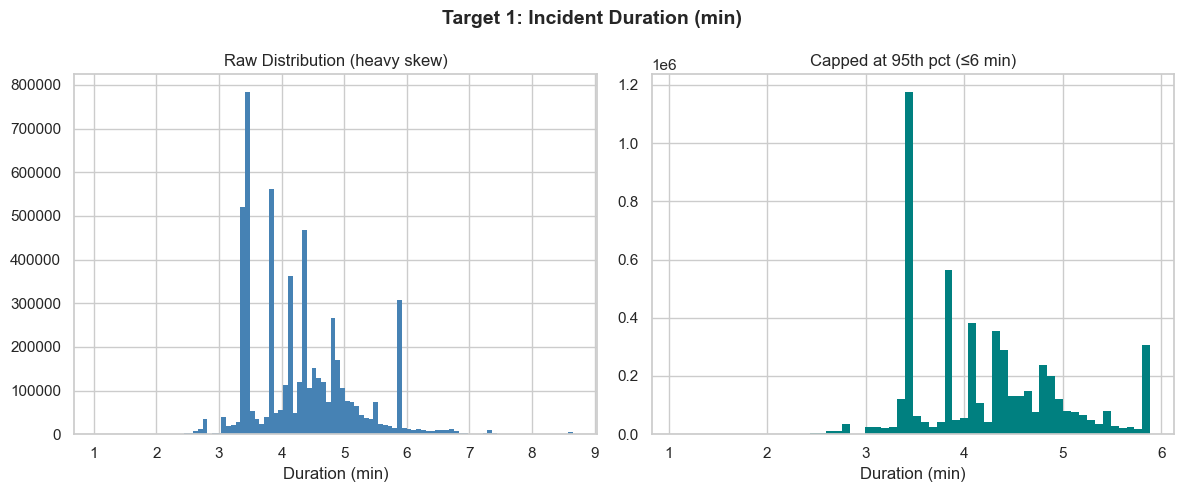

Duration stats:
  Mean:   4.3 min
  Median: 4.1 min
  95th:   5.9 min
  Max:    8.7 min


In [ ]:
# Duration (min) distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Target 1: Incident Duration (min)', fontsize=14, fontweight='bold')

# distribution
axes[0].hist(df['Duration(min)'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Distribution (heavy skew)')
axes[0].set_xlabel('Duration (min)')

# Cap at 95th percentile
cap95 = df['Duration(min)'].quantile(0.95)
df_cap = df[df['Duration(min)'] <= cap95]
axes[1].hist(df_cap['Duration(min)'], bins=60, color='teal', edgecolor='none')
axes[1].set_title(f'Capped at 95th pct (≤{cap95:.0f} min)')
axes[1].set_xlabel('Duration (min)')


plt.tight_layout()
plt.savefig('eda_01_duration_dist.png', dpi=150)
plt.show()

print(f"Duration stats:")
print(f"  Mean:   {df['Duration(min)'].mean():.1f} min")
print(f"  Median: {df['Duration(min)'].median():.1f} min")
print(f"  95th:   {cap95:.1f} min")
print(f"  Max:    {df['Duration(min)'].max():.1f} min")

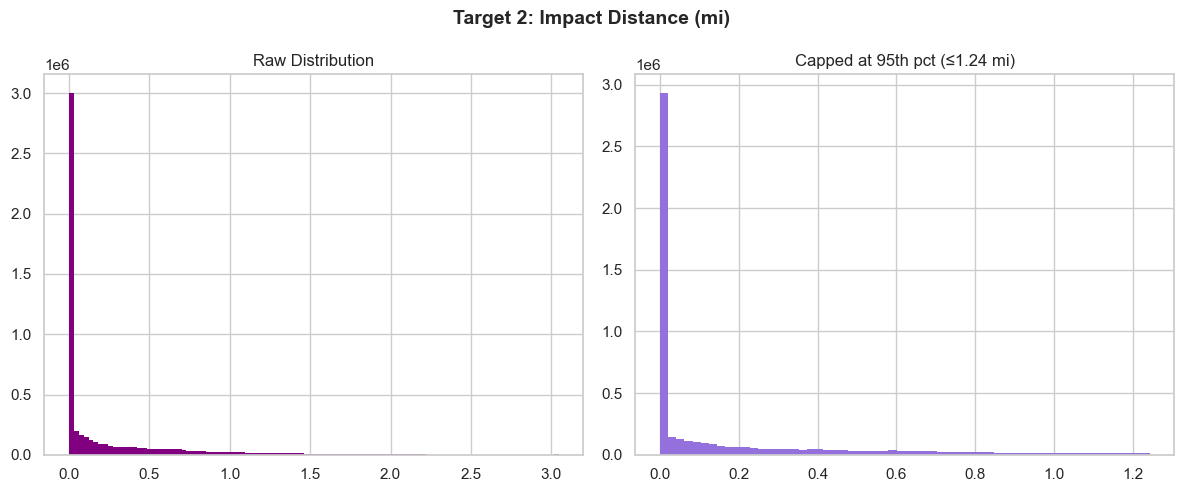

In [30]:
#Distance(mi)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # เปลี่ยนจาก (1,3) → (1,2)
fig.suptitle('Target 2: Impact Distance (mi)', fontsize=14, fontweight='bold')

axes[0].hist(df['Distance(mi)'], bins=100, color='purple', edgecolor='none')
axes[0].set_title('Raw Distribution')

cap95_d = df['Distance(mi)'].quantile(0.95)
axes[1].hist(df[df['Distance(mi)'] <= cap95_d]['Distance(mi)'],
             bins=60, color='mediumpurple', edgecolor='none')
axes[1].set_title(f'Capped at 95th pct (≤{cap95_d:.2f} mi)')

# ลบ axes[2] log transform ออกทั้งหมด

plt.tight_layout()
plt.savefig('eda_02_distance_dist.png', dpi=150)
plt.show()

raw, capped ที่ 95th percentileเพื่อดูว่าตัวแปรที่จะทำนาย "หน้าตา" เป็นยังไง ถ้า skew มาก หมายความว่ามีอุบัติเหตุส่วนน้อยที่กินเวลานานผิดปกติ เช่น อุบัติเหตุใหญ่บนทางด่วน เพราะมันจะพยายามไล่ตามค่า outlier มากเกินไป

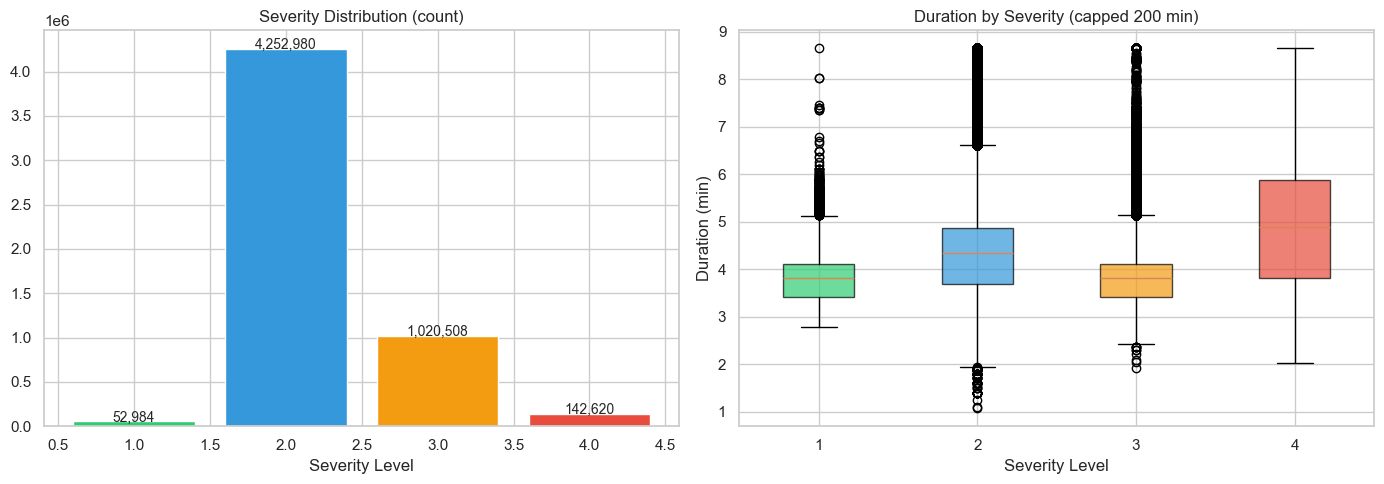

In [31]:
#Severity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sev_counts = df['Severity'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
axes[0].bar(sev_counts.index, sev_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Severity Distribution (count)')
axes[0].set_xlabel('Severity Level')
for i, (idx, val) in enumerate(sev_counts.items()):
    axes[0].text(idx, val + 500, f'{val:,}', ha='center', fontsize=10)

# Duration by severity (boxplot)
sev_order = [1, 2, 3, 4]
data_by_sev = [df[df['Severity'] == s]['Duration(min)'].clip(upper=200) for s in sev_order]
bp = axes[1].boxplot(data_by_sev, labels=sev_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Duration by Severity (capped 200 min)')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Duration (min)')

plt.tight_layout()
plt.savefig('eda_03_severity.png', dpi=150)
plt.show()

ดูว่า severity กระจายยังไง และแต่ละระดับทำให้ duration ต่างกันแค่ไหน ถ้า severity 4 duration นานกว่า severity 2 มาก แสดงว่า severity เป็น feature สำคัญที่ควรเอาใส่ model


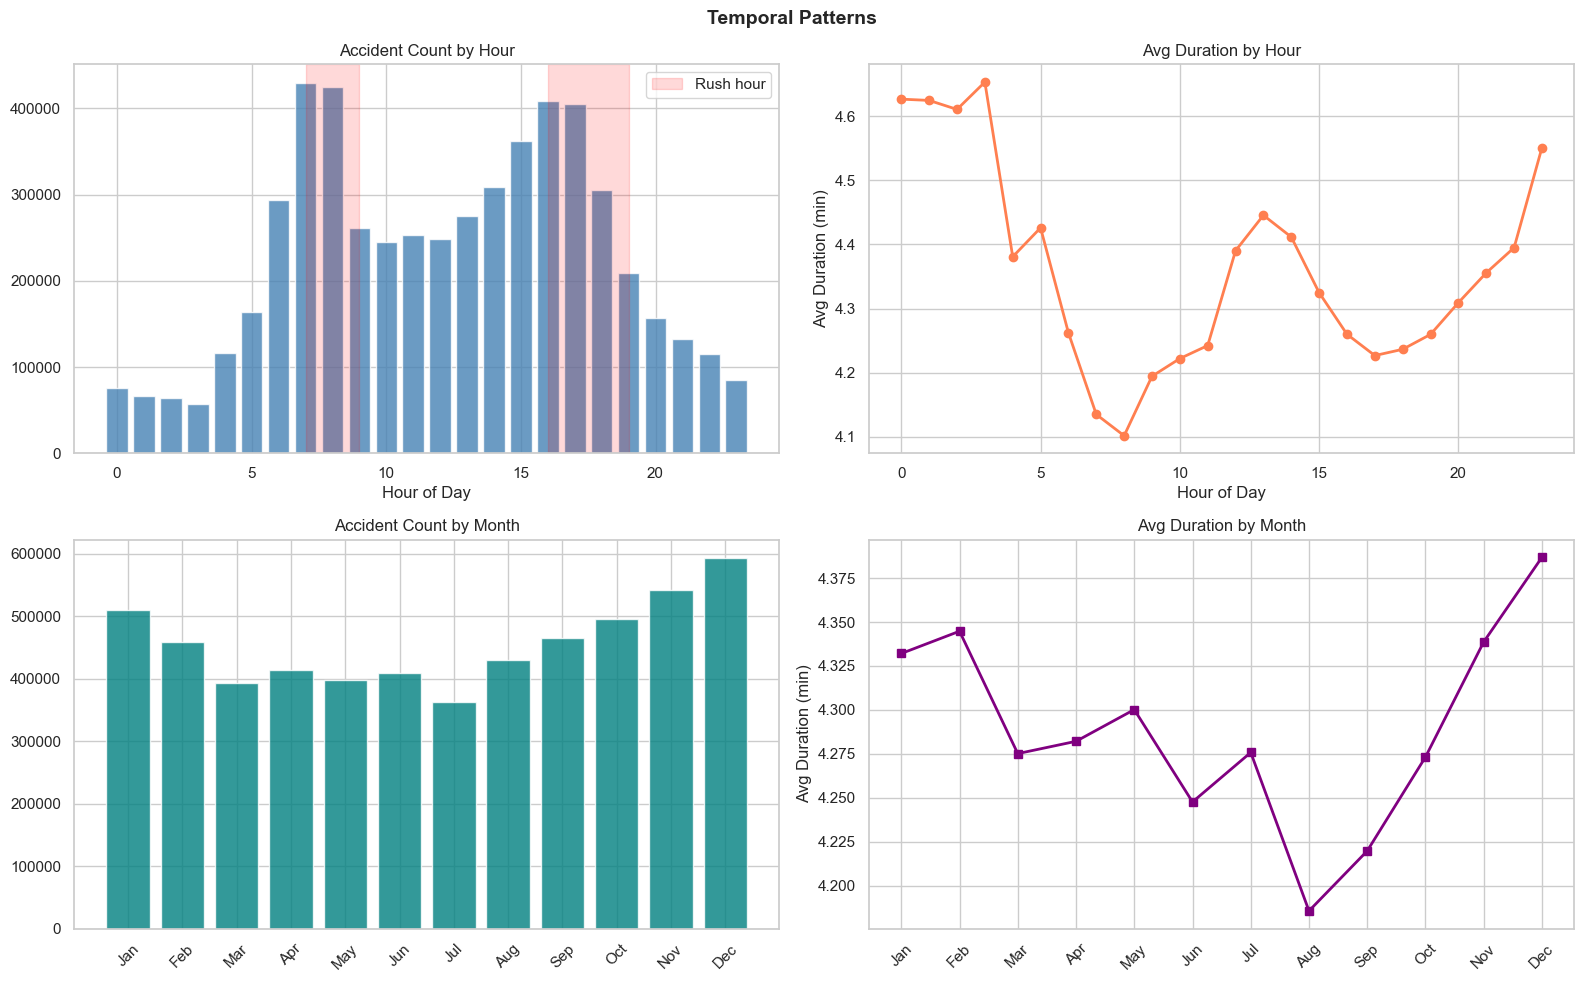

In [ ]:
# Temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Patterns', fontsize=14, fontweight='bold')

# By hour
hourly = df.groupby('Hour').agg(
    count=('Duration(min)', 'count'),
    avg_duration=('Duration(min)', 'mean'),
    avg_distance=('Distance(mi)', 'mean')
).reset_index()

axes[0,0].bar(hourly['Hour'], hourly['count'], color='steelblue', alpha=0.8)
axes[0,0].set_title('Accident Count by Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].axvspan(7, 9, alpha=0.15, color='red', label='Rush hour')
axes[0,0].axvspan(16, 19, alpha=0.15, color='red')
axes[0,0].legend()

axes[0,1].plot(hourly['Hour'], hourly['avg_duration'],
               color='coral', marker='o', linewidth=2)
axes[0,1].set_title('Avg Duration by Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Avg Duration (min)')

# By month
monthly = df.groupby('Month').agg(
    count=('Duration(min)', 'count'),
    avg_duration=('Duration(min)', 'mean')
).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

axes[1,0].bar(monthly['Month'], monthly['count'], color='teal', alpha=0.8)
axes[1,0].set_title('Accident Count by Month')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(month_names, rotation=45)

axes[1,1].plot(monthly['Month'], monthly['avg_duration'],
               color='purple', marker='s', linewidth=2)
axes[1,1].set_title('Avg Duration by Month')
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(month_names, rotation=45)
axes[1,1].set_ylabel('Avg Duration (min)')

plt.tight_layout()
plt.savefig('eda_04_temporal.png', dpi=150)
plt.show()

ดู pattern ตามเวลา 4 กราฟ คือ จำนวนต่อชั่วโมง, duration เฉลี่ยต่อชั่วโมง, จำนวนต่อเดือน, duration เฉลี่ยต่อเดือน เพื่อยืนยัน hypothesis ว่า rush hour และ winter มีอุบัติเหตุมากกว่าจริงไหม และ duration ต่างกันจริงไหม ถ้าใช่ feature ด้านเวลาก็จะมีประโยชน์กับ model

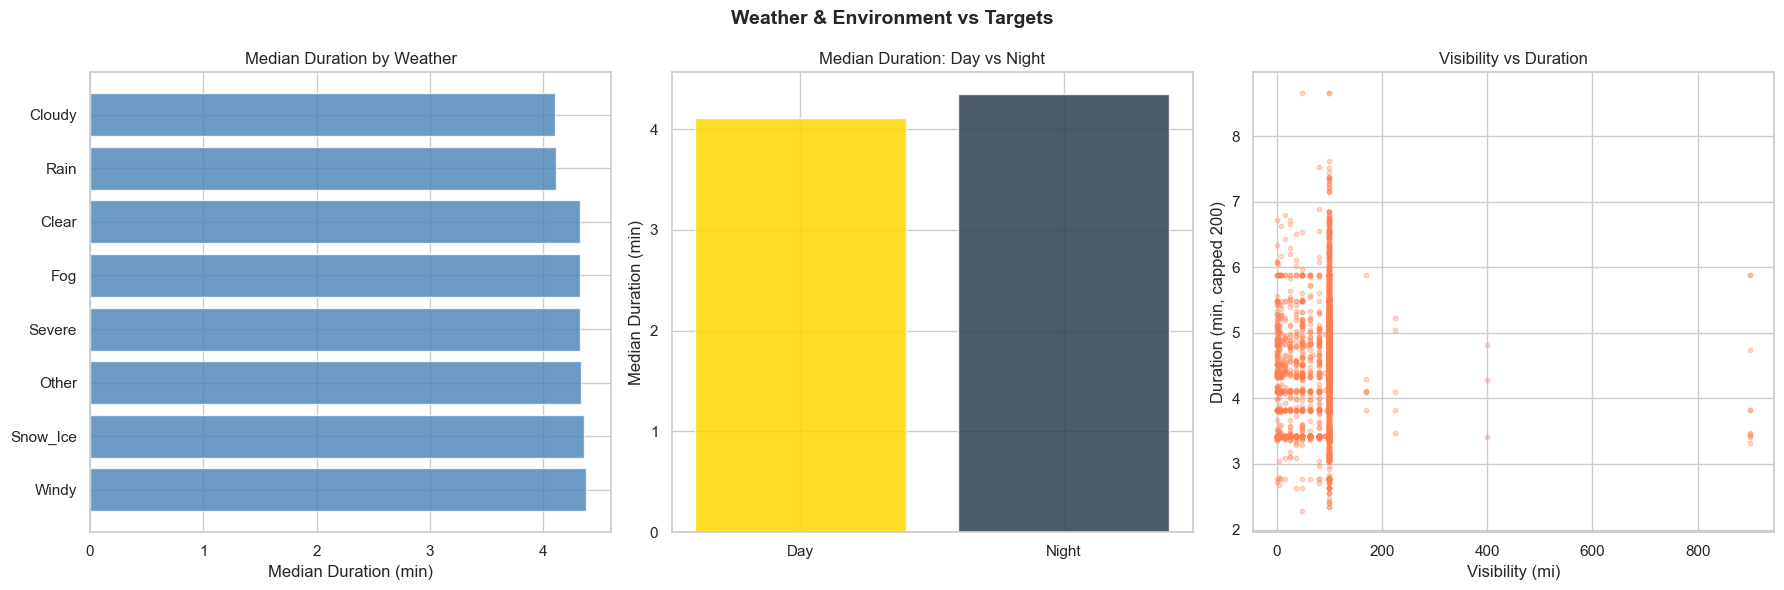

In [ ]:
# Weather & Environmental impact
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Weather & Environment vs Targets', fontsize=14, fontweight='bold')

# Weather group vs Duration
wg_stats = df.groupby('Weather_Group')['Duration(min)'].median().sort_values(ascending=False)
axes[0].barh(wg_stats.index, wg_stats.values, color='steelblue', alpha=0.8)
axes[0].set_title('Median Duration by Weather')
axes[0].set_xlabel('Median Duration (min)')

# Sunrise_Sunset vs Duration
ss_stats = df.groupby('Sunrise_Sunset')['Duration(min)'].median()
axes[1].bar(ss_stats.index, ss_stats.values,
            color=['#FFD700', '#2C3E50'], alpha=0.85, edgecolor='white')
axes[1].set_title('Median Duration: Day vs Night')
axes[1].set_ylabel('Median Duration (min)')

# Visibility vs Duration (scatter sample)
sample = df.sample(min(5000, len(df)), random_state=42)
axes[2].scatter(sample['Visibility(mi)'], sample['Duration(min)'].clip(upper=200),
                alpha=0.3, color='coral', s=10)
axes[2].set_title('Visibility vs Duration')
axes[2].set_xlabel('Visibility (mi)')
axes[2].set_ylabel('Duration (min, capped 200)')

plt.tight_layout()
plt.savefig('eda_05_weather.png', dpi=150)
plt.show()

เปรียบ median duration แต่ละสภาพอากาศและ กลางวัน/กลางคืน ใช้ median แทน mean เพราะข้อมูลมี outlier เยอะ median บอกค่ากลางที่ "จริง" กว่า ถ้า Fog มี duration สูงกว่า Clear มาก ก็ยืนยันว่า weather feature มีความสำคัญ

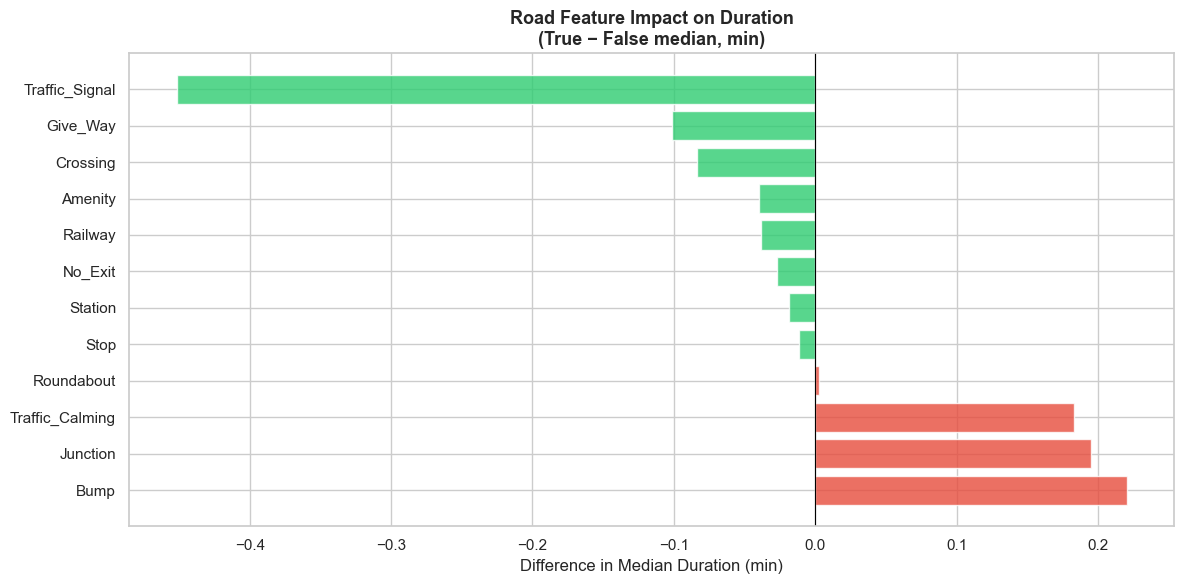

Road features with highest positive impact:
                 True  False  Diff
Bump             4.36   4.14  0.22
Junction         4.33   4.14  0.20
Traffic_Calming  4.33   4.14  0.18
Roundabout       4.15   4.14  0.00


In [ ]:
# Road features impact
road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

road_impact = {}
for feat in road_features:
    if feat in df.columns:
        true_med  = df[df[feat] == True]['Duration(min)'].median()
        false_med = df[df[feat] == False]['Duration(min)'].median()
        road_impact[feat] = {'True': true_med, 'False': false_med,
                             'Diff': true_med - false_med}

road_df = pd.DataFrame(road_impact).T.sort_values('Diff', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#e74c3c' if d > 0 else '#2ecc71' for d in road_df['Diff']]
ax.barh(road_df.index, road_df['Diff'], color=colors_bar, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Road Feature Impact on Duration\n(True − False median, min)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Difference in Median Duration (min)')
plt.tight_layout()
plt.savefig('eda_06_road_features.png', dpi=150)
plt.show()

print("Road features with highest positive impact:")
print(road_df[road_df['Diff'] > 0][['True','False','Diff']].round(2))

เปรียบว่าจุดที่มีสิ่งก่อสร้างนั้นๆ (เช่น Junction, Traffic_Signal) กับจุดที่ไม่มี duration ต่างกันแค่ไหน เพื่อดูว่า road feature ไหนมี "impact" มากพอที่จะเอาเข้า model ถ้าต่างกันมาก feature นั้นมีคุณค่า ถ้าต่างกันน้อยมาก ก็อาจ drop ได้


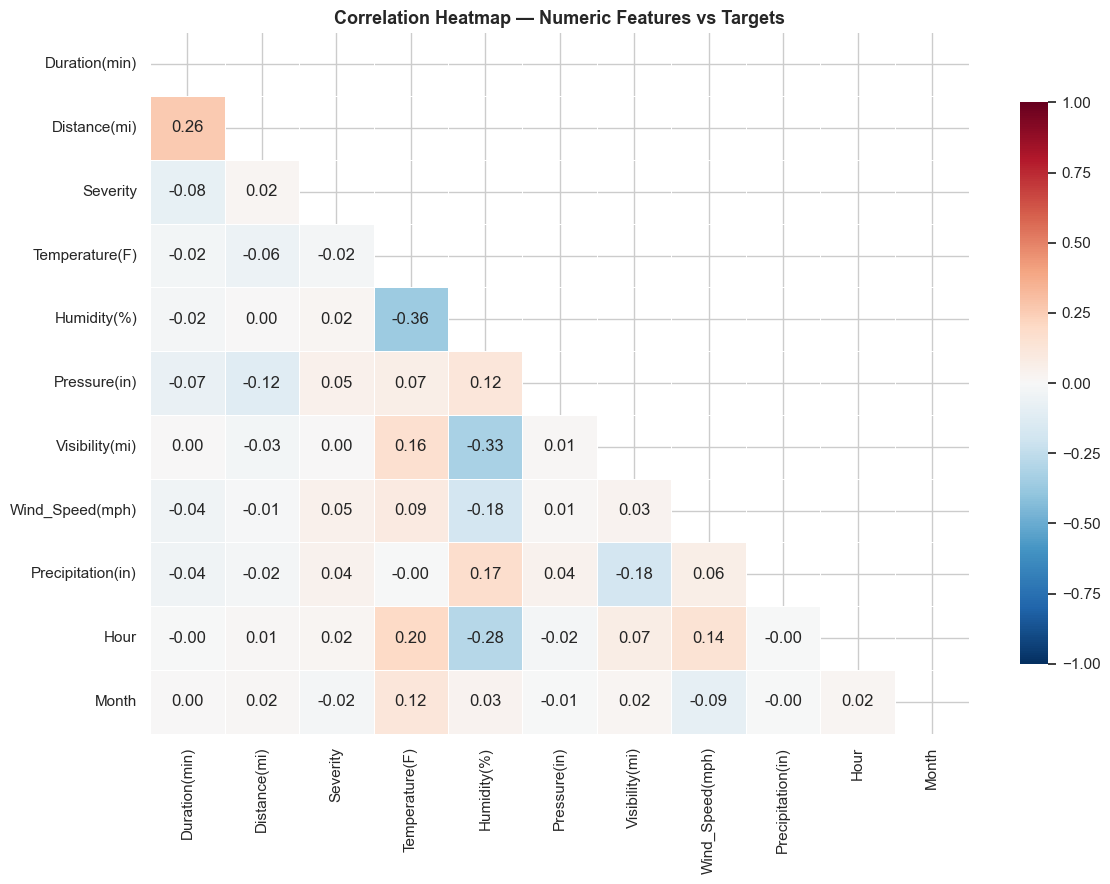

In [ ]:
# Correlation heatmap
num_cols = ['Duration(min)', 'Distance(mi)', 'Severity',
            'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
            'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
            'Hour', 'Month']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric Features vs Targets',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_correlation.png', dpi=150)
plt.show()

ดูว่า feature ไหน correlate กับ target (Duration, Distance) แค่ไหน และ feature คู่ไหน correlate กันเอง สูงเกินไป ถ้า feature A กับ B correlate กัน 0.95 ใส่ทั้งคู่ก็ไม่ได้ข้อมูลเพิ่ม แต่เพิ่ม noise ให้ model แทน


In [36]:
#Key Insights Summary
insights = {
    'Duration skew':    f"Median={df['Duration(min)'].median():.1f} min, Mean={df['Duration(min)'].mean():.1f} min → use log transform",
    'Distance skew':    f"Median={df['Distance(mi)'].median():.3f} mi, Mean={df['Distance(mi)'].mean():.3f} mi → use log transform",
    'Peak hours':       "07:00-09:00 and 16:00-19:00 have highest accident count",
    'Night effect':     f"Night median = {df[df['Sunrise_Sunset']=='Night']['Duration(min)'].median():.1f} min vs Day = {df[df['Sunrise_Sunset']=='Day']['Duration(min)'].median():.1f} min",
    'Severity 2 dominant': f"{(df['Severity']==2).mean()*100:.1f}% of all accidents",
}

print("=" * 60)
print("KEY EDA INSIGHTS")
print("=" * 60)
for k, v in insights.items():
    print(f"  {k}:\n    → {v}\n")

KEY EDA INSIGHTS
  Duration skew:
    → Median=4.1 min, Mean=4.3 min → use log transform

  Distance skew:
    → Median=0.010 mi, Mean=0.250 mi → use log transform

  Peak hours:
    → 07:00-09:00 and 16:00-19:00 have highest accident count

  Night effect:
    → Night median = 4.3 min vs Day = 4.1 min

  Severity 2 dominant:
    → 77.8% of all accidents



อุบัติเหตุส่วนใหญ่ไม่ได้ร้ายแรงมากแต่ว่าจะทำให้รถติดประมาณ 3-5นาที กลางคืนถ้าเกิดอุบัติเหตุรถจะติดกว่าช่วงกลางวันเพราะว่าทัศนวิสัยต่ำ + จำนวนกำลังเจ้าหน้าที่รัฐหรือกู้ภัย standby จำนวนน้อยกว่ากลางวัน โดยจุดอันตรายที่เกิดอุบัติเหตุบ่อยที่สุดคือ ช่วง Rush hour 7.00-9.00โมงเช้า, 16.00-19.00 และช่วงกลางคืนเพราะว่ารถโล่งเลยทำความเร็วได้มาก

ด้าน weather fog กับ snow กับ ice ทำให้รถติดนานที่สุดแต่จำนวนการเกิดเหตุจะน้อยกว่า rain แต่ rain ความรุนแรงมากกว่าและบ่อยกว่า

มีจุดที่เกิดเหตุเดิมซ้ำหลายร้อยจุดที่เกิดซ้ำทุกปี ดูจาก grid cell ที่เกิด มากกว่า5 ครั้ง ต่อปีและเกิดมากกว่า2ปีติด สรุปได้ว่าจุดนั้นมีปัญหาทางโครงสร้างถนนความสว่าง หรือ อื่นๆ

จุดที่เป็น junction + No Exit รถติดค้าง ช่วยเหลือยากที่สุด ระยะเวลา เฉลี่ยสูงกว่าจุดอื่นๆ